This Is The Last Part Of The Data Analysis Final Project Which Requires Us To Analyze The Data Using Plt, Sns And Also Math Equations With The Cleaned Dataset From The First Part.

# EDA:

# The Imports And Dataset:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Datasets/Dataset_Cleaned.csv')

# I dropped the order column because it was just the order of the rows and it didn't add any value to the dataset at all :P.

if 'Order' in df.columns:
    df = df.drop(columns=['Order'])
print(df.shape)

(2897, 81)


# Histogram / KDE Distribution:

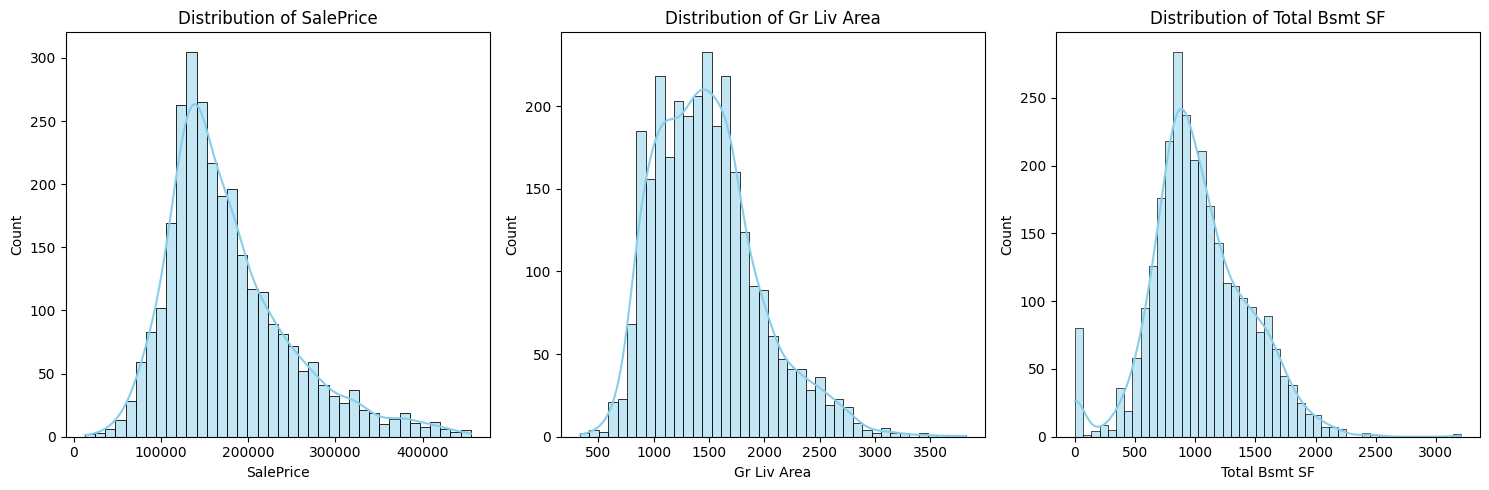

In [ ]:
features = ['SalePrice', 'Gr Liv Area', 'Total Bsmt SF']
plt.figure(figsize=(15, 5))

for i, col in enumerate(features):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# Catagorical Comparison:

C:\Users\mesha\AppData\Local\Temp\ipykernel_3872\1662214988.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Overall Qual', y='SalePrice', data=df, palette='viridis')


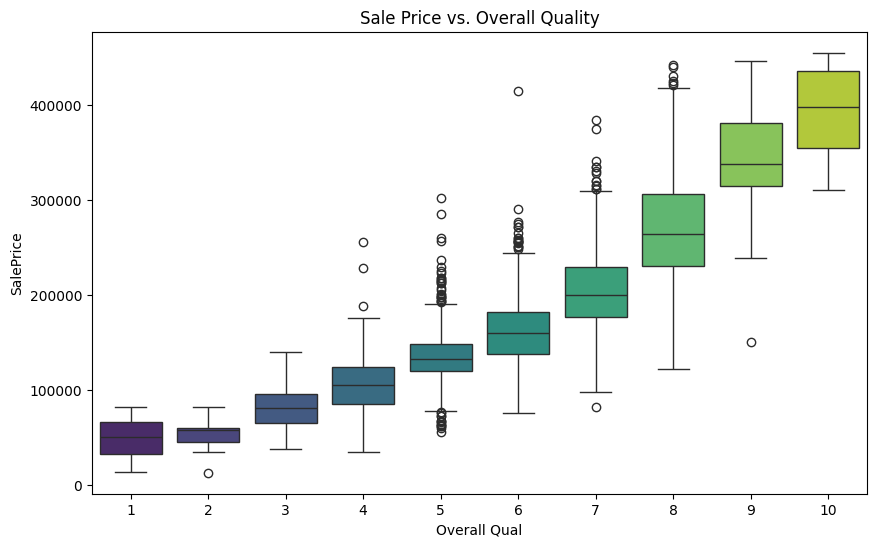

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Overall Qual', y='SalePrice', data=df, palette='viridis')
plt.title('Sale Price vs. Overall Quality')
plt.show()

# Heatmap Correlation "Top 10 Features":

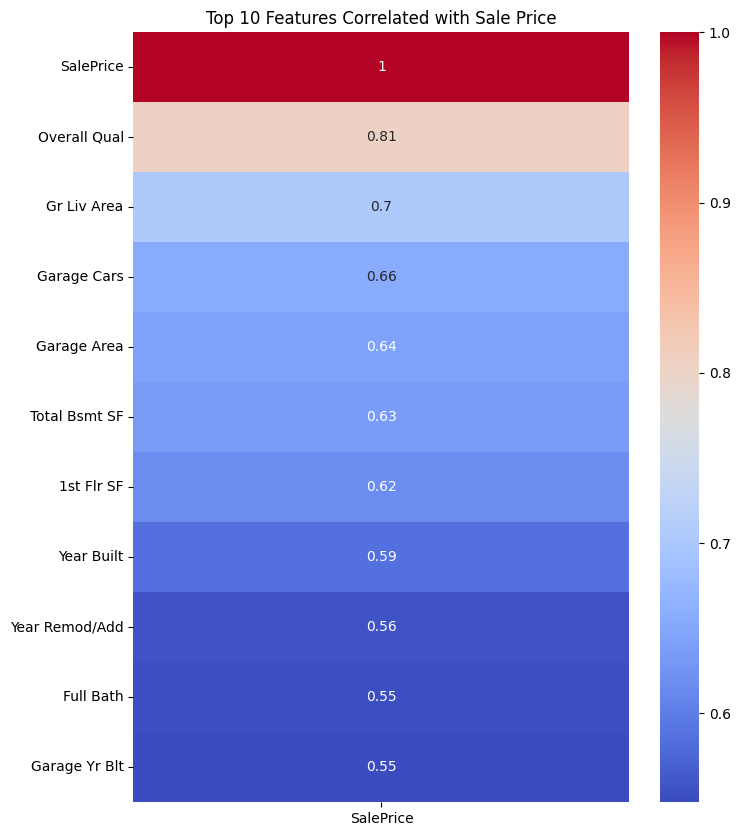

In [5]:
plt.figure(figsize=(8, 10))
top_10_corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False).head(11) # 11 because SalePrice correlates 100% with itself
sns.heatmap(top_10_corr.to_frame(), annot=True, cmap='coolwarm')
plt.title('Top 10 Features Correlated with Sale Price')
plt.show()

# Math:

# Mean And Std dev:

In [3]:
# Use the SalePrice column as a np array
target = df['SalePrice'].to_numpy()

# 1. Mean
mean = np.sum(target) / len(target)

# 2. Std Dev
# We subtract the mean from every element (broadcasting), square it, sum it, and divide
std = np.sqrt(np.sum((target - mean)**2) / len(target))

print(f"Mean: {mean:.2f}")
print(f"Std Dev: {std:.2f}")

Mean: 177095.12
Std Dev: 71063.53


# Manual Std "Broadcasting":

In [4]:
from sklearn.preprocessing import StandardScaler

# Choose a column (e.g., Gr Liv Area)
column_name = 'Gr Liv Area'
X_raw = df[column_name].to_numpy()

# Standardize by hand using broadcasting
z_manual = (X_raw - np.mean(X_raw)) / np.std(X_raw)

# Standardize using StandardScaler
scaler = StandardScaler()
z_sklearn = scaler.fit_transform(df[[column_name]]).flatten()

# Compare the first 5 values to prove they match
print("Manual Z-scores:", z_manual[:5])
print("Sklearn Z-scores:", z_sklearn[:5])

Manual Z-scores: [ 0.36856781 -1.24318386 -0.32490955  1.33137736  0.31130821]
Sklearn Z-scores: [ 0.36856781 -1.24318386 -0.32490955  1.33137736  0.31130821]


# Cosine Similarity:

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

# Get the record for the highest and lowest SalePrice
# We drop 'SalePrice' because we only want to compare features
high_val_house = df.nlargest(1, 'SalePrice').drop(columns=['SalePrice']).select_dtypes(include=[np.number])
low_val_house = df.nsmallest(1, 'SalePrice').drop(columns=['SalePrice']).select_dtypes(include=[np.number])

# Compute similarity
sim_score = cosine_similarity(high_val_house, low_val_house)

print(f"Cosine Similarity between highest and lowest value house: {sim_score[0][0]:.4f}")

Cosine Similarity between highest and lowest value house: 1.0000


# Probability Estimation:

In [6]:
# Define "High Quality" as Overall Qual > 8
high_quality_df = df[df['Overall Qual'] > 8]

# Define "Threshold" as the mean SalePrice
threshold = df['SalePrice'].mean()

# Calculate the fraction
fraction = len(high_quality_df[high_quality_df['SalePrice'] > threshold]) / len(high_quality_df)

print(f"Probability that a high quality house is priced above average: {fraction:.2%}")

Probability that a high quality house is priced above average: 99.06%
